In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings('ignore')
import numpy.fft as fft
mc = 'mediumorchid'

## Exercise 2: image deconvolution.

We are used to seeing, in movies or television series with a police theme, scenes in which a technician transforms a blurry image into a sharp one almost by magic.  
In fact, there is no magic at all: it is simply Fourier analysis.

In a blurry image, each point is spread out according to a distribution that we call the point spread function.  
To simplify the problem, let us assume that we are working with a black-and-white image, so the image can be represented by a single function \( a(x,y) \) that determines the brightness of a point \( (x,y) \) in the image.

Let us define the point spread function as \( f(x,y) \), which causes the brightness (value) of a point \( (x,y) \) in the original image to be distributed according to \( f(x,y) \). If \( f(x,y) \) is a broad function, the image will be strongly blurred. However, if the function is described by a very narrow peak, then the image can be acceptably sharp.

In general, the brightness of the blurred image \( b(x,y) \) can be described by a convolution function, which describes how the brightness of the original image has been redistributed:

\[
b(x,y)=\int_{0}^K\int_0^L a(x',y')f(x-x',y-y')\,\text{d}x'\text{d}y',
\]

where \( K \) and \( L \) are the dimensions of the image along each axis. This equation is known as the convolution of the image with the point spread function.

To explain how the deconvolution technique (recovery of a blurred image) works, let us first work in one dimension (the generalization to higher dimensions is trivial). The convolution of an image in one dimension is given by:

\[
b(x)=\int_0^L a(x')f(x-x')\,\text{d}x'.
\]

This function can be represented by a Fourier series as:

\[
b(x)=\sum_{k=-\infty}^\infty{\bar b_k\exp\left(i\frac{2\pi k x}{L}\right)},
\]

where the Fourier coefficients are given by:

\begin{align}
\bar b_k=&\frac{1}{L}\int_0^L{b(x)\exp{\left(-i\frac{2\pi k x}{L}\right)}\text{d}x}\nonumber\\
=&\frac{1}{L}\int_0^L\int_0^La(x')f(x-x')\,\exp{\left(-i\frac{2\pi k x}{L}\right)}\,\text{d}x\,\text{d}x'\nonumber\\
=& \frac{1}{L}\int_0^La(x')\,\exp{\left(-i\frac{2\pi k x'}{L}\right)}\int_{-x'}^{L-x'}f(x'')\,\exp{\left(-i\frac{2\pi k x''}{L}\right)}\,\text{d}x\,\text{d}x'',
\end{align}

where in the last step we have defined \( x''=x-x' \).

If we now make \( f(x) \) a periodic function by repeating it infinitely to the left and right of its interval, the second integral

\begin{align}
\int_{-x'}^{L-x'}f(x'')\,\exp{\left(-i\frac{2\pi k x''}{L}\right)}\,\text{d}x''=&\int_{-x'}^{0}f(x'')\,\exp{\left(-i\frac{2\pi k x''}{L}\right)}\,\text{d}x''+\int_{0}^{L-x'}f(x'')\,\exp{\left(-i\frac{2\pi k x''}{L}\right)}\,\text{d}x''\nonumber\\
=&\int_{L-x'}^{L}f(x'')\,\exp{\left(-i\frac{2\pi k x''}{L}\right)}\,\text{d}x''+\int_{0}^{L-x'}f(x'')\,\exp{\left(-i\frac{2\pi k x''}{L}\right)}\,\text{d}x''\nonumber\\
=&\int_{0}^{L}f(x'')\,\exp{\left(-i\frac{2\pi k x''}{L}\right)}\,\text{d}x''=L \bar f_k,
\end{align}

is nothing but the Fourier transform \( \bar f_k \) of \( f(x) \) multiplied by \( L \).

Therefore,

\[
\bar b_k=\bar f_k\int_0^La(x')\,\exp{\left(-i\frac{2\pi k x'}{L}\right)\,\text{d}x}=L\bar f_k\bar a_k,
\]

that is, the Fourier transform of the blurred image is given by the product of the Fourier transform of the original image and that of the point spread function.

To recover the original image, we therefore only need to take the Fourier transform of the blurred image, do the same with the point spread function, and take their quotient divided by the size of the interval, obtaining

\[
\bar a_k=\frac{\bar b_k}{L \bar f_k}.
\]

Finally, we only need to perform the inverse Fourier transform to recover the sharp image.  
This is known as the deconvolution process.

The process for a two-dimensional image is completely equivalent. For an image of dimensions \( L\times K \) one obtains

\[
\bar b_{kl}=KL\bar a_{kl}\bar f_{kl}.
\]

The only complication associated with the deconvolution process of an image is that, a priori, we do not know what the point spread function is, so one has to try several alternatives until a satisfactory result is obtained.

Most cameras, however, involve a point spread function that can be described quite satisfactorily as a Gaussian function:

\[
f(x,y)=\exp\left(-\frac{x^2+y^2}{2\sigma^2}\right),
\]

where the value of the standard deviation \( \sigma \) is unknown.  
This is, for example, the procedure that was used to obtain the first sharp image of a black hole.

---

1. The file called blur.txt contains a grid of values that represent the brightness of a black-and-white image that has been blurred by means of a Gaussian point spread function with standard deviation \( \sigma=25 \). Write a program that reads the grid of values and displays the distorted image using a density plot.

---


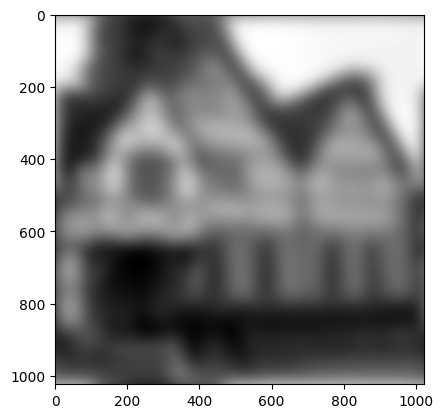

In [2]:
blur = np.loadtxt("blur.txt")
N, M = np.shape(blur)

plt.imshow(blur, cmap='gray')
plt.show()

2. Write another program that creates an array of the same size as the one containing the image file, filled with the values of a Gaussian function with standard deviation $\sigma = 25$. Remember that the function must be periodic along both axes.

---


In [3]:
def scattering(image, s):
    def f(x, y, s):
        return np.exp(-(x**2 + y**2) / (2 * s**2))
    
    N, M = np.shape(image)
    disp = np.zeros([N, M], float)
    
    for y in range(N):
        yy = y
        if y > N / 2:
            yy -= N
        for x in range(M):
            xx = x
            if x > M / 2:
                xx -= M
            disp[y, x] = f(xx, yy, s)
    
    return disp

3. Compute the Fourier transform of the image and of the point spread function and combine them to obtain the Fourier coefficients of the sharp image.  
   Finally, perform the inverse transform to recover the undistorted image and display it using a density plot.
   
   [Hint: when doing this you may encounter the problem that the Fourier transform of the point spread function at some point may be zero or so small that it produces an overflow. In that case, a lower bound \(\epsilon \sim 10^{-3}\) can be used to replace the value of the coefficient whenever it is smaller than that value].

---


In [4]:
def deconvolution(image, s, eps):
    K, L = np.shape(image)
    
    bkl = fft.rfft2(image)
    fkl = fft.rfft2(scattering(image, s))
    
    N, M = np.shape(fkl)
    for i in range(N):
        for j in range(M):
            if fkl[i, j] < eps:
                fkl[i, j] = eps
    
    akl = bkl / (K * L * fkl)
    fixed_image = fft.irfft2(akl)
    
    plt.imshow(fixed_image, cmap='gray')
    plt.grid()
    plt.show()
    
    return fixed_image

4. What is the factor that limits our ability to filter images? Why is it not possible to make a distorted image completely sharp?

---


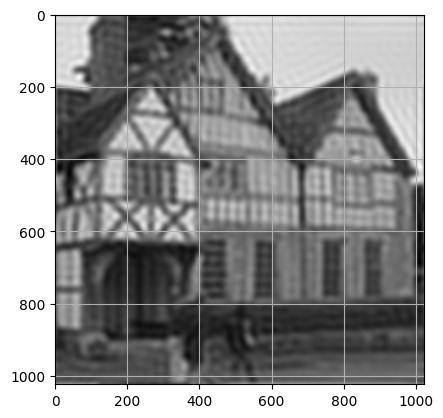

In [5]:
a = deconvolution(blur,25,1e-3)